In [ ]:
#import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#load the dataset
ds=pd.read_csv('/content/Ice_cream selling data.csv')
print('DataSet loaded successfully');

DataSet loaded successfully


In [ ]:
ds.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [ ]:
ds.shape

(49, 2)

In [ ]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


In [ ]:
ds.describe()

,Temperature (°C),Ice Cream Sales (units)
count,49.000000,49.000000
mean,0.271755,15.905308
std,2.697672,12.264682
min,-4.662263,0.328626
25%,-2.111870,4.857988
50%,0.688781,12.615181
75%,2.784836,25.142082
max,4.899032,41.842986


In [ ]:
#detecting missing values
ds.isnull().sum()

,0
Temperature (°C),0
Ice Cream Sales (units),0


In [ ]:
# Check duplicate records
print(ds.duplicated().sum())

0


<Axes: ylabel='Temperature (°C)'>

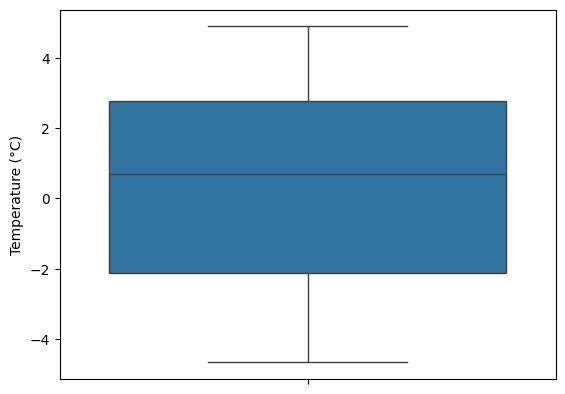

In [ ]:
#Outlier detection
sns.boxplot(ds['Temperature (°C)'])


In [ ]:
#Independent
x=ds['Temperature (°C)']
x

,Temperature (°C)
0,-4.662263
1,-4.316559
2,-4.213985
3,-3.949661
4,-3.578554
5,-3.455712
6,-3.108440
7,-3.081303
8,-2.672461
9,-2.652287


In [ ]:
#Dependent
y=ds['Ice Cream Sales (units)']
y

,Ice Cream Sales (units)
0,41.842986
1,34.661120
2,39.383001
3,37.539845
4,32.284531
5,30.001138
6,22.635401
7,25.365022
8,19.226970
9,20.279679


Text(0, 0.5, 'Ice Cream Sales (units)')

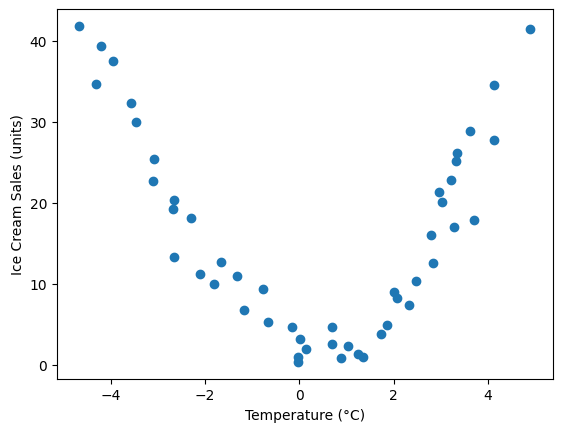

In [ ]:
plt.scatter(x,y)
plt.xlabel('Temperature (°C)')
plt.ylabel('Ice Cream Sales (units)')

In [ ]:
#split the data into training and testing
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
print(f"number of instances for training:{len(x_train)}")
print(f"number of instances for testing:{len(x_test)}")

number of instances for training:39
number of instances for testing:10


In [ ]:
poly_features=PolynomialFeatures(degree=2)

In [ ]:
x_poly=poly_features.fit_transform(x.to_frame())

In [ ]:
lr_model=LinearRegression()
lr_model.fit(x_poly,y)

LinearRegression()

In [ ]:
model.fit(x_train_poly, y_train)
print("Model Trained Successfully")

NameError: name 'model' is not defined

In [ ]:
y_pred = lr_model.predict(x_test_poly)
df=pd.DataFrame({'Actual':y_test,'Predicted':y_pred})
x_test_poly = poly_features.transform(x_test.to_frame())
print(df)

       Actual  Predicted
13  10.012868  10.504868
45  17.843957  24.998282
47  27.698383  30.802396
44  28.912188  23.826884
17   9.392969   4.683654
27   2.313806   4.026226
26   0.789974   3.630683
25   4.625689   3.259923
31   4.857988   7.690948
19   4.673643   3.116139


In [ ]:
# Evaluate model performance on training data using MAE, MSE, RMSE, and R2 score
y_train_pred = model.predict(x_train_poly)
mae = mean_absolute_error(y_train, y_train_pred)
mse = mean_squared_error(y_train, y_train_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_train_pred)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root MSE (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 2.5993732834161136
Mean Squared Error (MSE): 8.995867597495232
Root MSE (RMSE): 2.99931118717202
R2 Score: 0.9413665676490518


In [ ]:
# Evaluate model performance on testing data using MAE, MSE, RMSE, and R2 score
x_test_poly = poly_features.transform(x_test.to_frame())
y_test_pred = model.predict(x_test_poly)
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root MSE (RMSE):", rmse)
print("R2 Score: ", r2)

Mean Absolute Error (MAE): 3.2299819836597274
Mean Squared Error (MSE): 14.878796440981484
Root MSE (RMSE): 3.857304297171988
R2 Score:  0.843055137193884


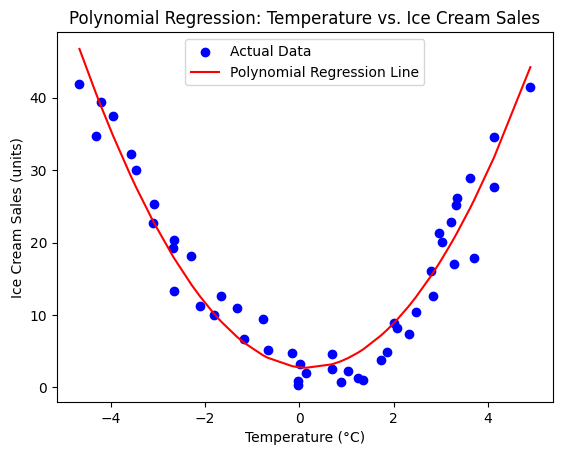

In [ ]:
plt.scatter(x, y, color='blue', label='Actual Data')
plt.plot(x, model.predict(poly_features.transform(x.to_frame())), color='red', label='Polynomial Regression Line')
plt.xlabel('Temperature (°C)')
plt.ylabel('Ice Cream Sales (units)')
plt.title('Polynomial Regression: Temperature vs. Ice Cream Sales')
plt.legend()
plt.show()